In [349]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [350]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize']=(8,5)

base_path=Path("/content/drive/MyDrive/wyzwanie-aiml/2/")

# Klasyfikacja pasażerów Titanica
Nie wiemy czy dla DiCaprio było miejsce na drzwiach, ale wiemy że grdyby był tam Wojfer87 to by z nimi wyciskał pompki na górze lodowej. Teraz twoja pora na wyciskanie.
#Twoje zadnie to:
**stworzenie modelu przewidującego szanse przeżycia katastrofy Titanica**.

![https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png](https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png "Wojfer")



#### Twoim celem będzie jest wytrenowanie modeli do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

Poniżej znajdziesz pytania, które mogą być pomocne w zadaniu:

- Czego nauczyło Cię o badanym zbiorze danych poprzednie zadanie? Jak możesz wykorzystać wyciągnięte z niego wnioski w procesie tworzenia modelu?
- Jak przeprowadzenie standaryzacji danych może wpływać na zachowanie modelu?
- Co mój model robi i w jaki sposób?
- Jak nie przetrenować wybranego modelu?
- Jaki wynik klasyfikacji możemy uznać za *dobry*?


Wymagania:
- Wypisz obserwacje z pierwszego zadania, które pomogą Ci w tym. Co było przydatne, a co okazało się bezużyteczne?
- [Nie doprowadź](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do ~~przecieku statku~~ wycieku danych (np. nie ucz modelu na danych testowych). Nauczone modele odpal na danych treningowych i testowych - opisz uzyskane wyniki.
- Stwórz baseline, czyli dla porównania sprawdź jak z zadaniem radzi sobie [Dummy Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) (jeśli Twój docelowy model radzi sobie gorzej - uciekaj)
- Przeprowadź badania na dwóch wybranych modelach uczenia maszynowego (np. spośród: drzew decyzyjnych, SVM, MLP, KNN, z gwiazdką [XGBoost](https://xgboost.readthedocs.io/en/stable))
- W badaniach użyj wybranych metryk. Wybór uzasadnij.
- Dla każdego modelu wybierz co najmniej dwa hiperparametry i przeprowadź badania zależności wyników metryk od wartości hiperparametrów. Zwizualizuj wszystko ładnie, zastanów się dlaczego tak mogło być i wyciągnij i wypisz wnioski.
- Podsumuj przeprowadzone badania, wypisz wnioski.

Niezmiennie, zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Jeśli chcesz, możesz sprawdzić (przyjmując pewne założenia), jakie byłyby Twoje szanse na Titanicu.

Uwaga! Jeśli Titanic to dla Ciebie nic i baaaaardzo chcesz to możesz w ramach tego zadania zająć się [bardziej wymagającym](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data) zbiorem.

In [351]:
df=pd.read_csv(base_path/'titanic.csv',index_col='PassengerId')
df['Cabin'].str[0].unique()

array([nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

0. WNIOSKI Z 1. ZADANIA

przydante okazaly sie:

plec gdyz kobiety przezywaly w 74% a mezczyzni w 19%

klasa i cena biletu dodatnio wplywaly na przezycie

tytuly wyciagnete z imienia gdyz przyblizaly plec i wiek

rozmiar rodziny wplywal ujemnie na szanse

osatecznie zbior jest niezbalansowany wiec metryka bedzie F1-score a nie tylko Accuracy

nieprzydatne okazaly sie:

dane o biletach, kabinach i id pasazerow

1. PREPROCESSING

In [352]:
#tytul z imiena
def gettitle(name):
  return name.split(',')[1].split('.')[0].strip()
freqtitles={'Mr','Miss','Mrs','Master'}
def getgrouptitles(name):
  title=name.split(',')[1].split('.')[0].strip()
  if title in freqtitles:
    return title
  return 'Other'
df['Title']=df['Name'].apply(getgrouptitles)
# wielkosc rodziny
df['FamilySize']=df['SibSp']+df['Parch']+1
df['IsAlone']=(df['FamilySize']==1).astype(int)
df.loc[df['FamilySize']==1,'IsAlone']=1
# poklad z kabiny
def getdeck(cabin):
  if pd.notnull(cabin):
    return cabin[0]
  return 'U'
df['Deck']=df['Cabin'].apply(getdeck)
# uzupelnienie brakow
def fillage(row,median):
  if pd.isnull(row['Age']):
    return median.loc[row['Pclass'],row['Sex']]
  return row['Age']

agemedians=df.groupby(['Pclass','Sex'])['Age'].median()
df['Age']=df.apply(fillage,axis=1,args=(agemedians,))

faremedians=df.groupby('Pclass')['Fare'].median()
def fillfare(row,median):
  if pd.isnull(row['Fare']):
    return median.loc[row['Pclass']]
  return row['Fare']
df['Fare']=df.apply(fillfare, axis=1,args=(faremedians,))
modeembarked=df['Embarked'].mode()[0]
df['Embarked']=df['Embarked'].fillna(modeembarked)
# usuniecie kolumn
df=df.drop(columns=['Name','Ticket','Cabin'])
# zakodowanie cech (kategorii)
df['Sex']=df['Sex'].map({'male':0,'female':1})
df=pd.get_dummies(df,columns=['Embarked','Title','Deck'],drop_first=True)
bool_cols=df.select_dtypes(include='bool').columns
df[bool_cols]=df[bool_cols].astype(int)

print(f'ksztalt zbioru: {df.shape}')
print(f'brakujace wartosci: {df.isnull().sum().sum()}')
df.head(3)


ksztalt zbioru: (891, 23)
brakujace wartosci: 0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Embarked_Q,...,Title_Mrs,Title_Other,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_U
PassengerId,,,,,,,,,,,,,,,,,,,,,
1,0,3,0,22.0,1,0,7.2500,2,0,0,...,0,0,0,0,0,0,0,0,0,1
2,1,1,1,38.0,1,0,71.2833,2,0,0,...,1,0,0,1,0,0,0,0,0,0
3,1,3,1,26.0,0,0,7.9250,1,1,0,...,0,0,0,0,0,0,0,0,0,1


2. PODZIAL DANYCH I STANDARYZACJA

z racji na calkiem neiwielki zbior danych podzielilem go na treningowy (80%) i testowy (20%)

oczywisnie zeby uniknac leaku nie uzywalem zbioru testowego do szukania hiperparametrow

natomiast do szukania najlepszych ustawien wykorzystalem walidacje krzyzowa

In [353]:
X=df.drop(columns=['Survived'])
y=df['Survived']
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
scaler=StandardScaler()
Xtrainsc=scaler.fit_transform(Xtrain)
Xtestsc=scaler.transform(Xtest)

print(f'zbior treningowy: {Xtrain.shape[0]} probek')
print(f'zbior testowy: {Xtest.shape[0]} probek')

zbior treningowy: 712 probek
zbior testowy: 179 probek


3. FUNKCJA OCENY

In [354]:
def finalmark(model,Xtrain,ytrain,Xtest,ytest,title):
  model.fit(Xtrain,ytrain)
  ytrainpred=model.predict(Xtrain)
  ytestpred=model.predict(Xtest)

  print(f'{title}')
  print('wyniki treningowe:')
  print(f'Accuracy: {accuracy_score(ytrain,ytrainpred):.4f}')
  print(f'F1-score: {f1_score(ytrain,ytrainpred):.4f}')
  print('\nwyniki testowe:')
  print(f'Accuracy: {accuracy_score(ytest,ytestpred):.4f}')
  print(f'F1-score: {f1_score(ytest,ytestpred):.4f}')

  cm=confusion_matrix(ytest,ytestpred)
  plt.figure(figsize=(5,4))
  sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['zginal','przezyl'],yticklabels=['zginal','przezyl'])
  plt.title(f'confusion matrix {title}')
  plt.xlabel('przewidziano')
  plt.ylabel('rzeczywistosc')
  plt.show()
  return model


4. BASELINE

dummy classifier obstawia najczestsza klase

dummy classifier
wyniki treningowe:
Accuracy: 0.6166
F1-score: 0.0000

wyniki testowe:
Accuracy: 0.6145
F1-score: 0.0000


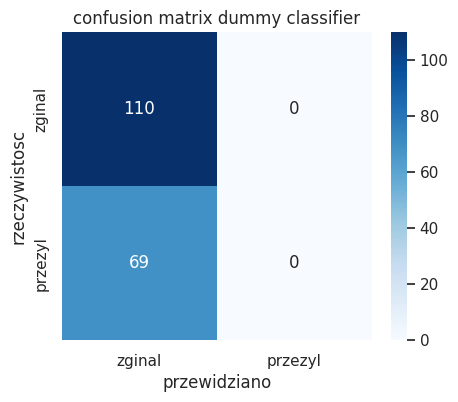

DummyClassifier(strategy='most_frequent')

In [355]:
dummy=DummyClassifier(strategy='most_frequent')
finalmark(dummy,Xtrainsc,ytrain,Xtestsc,ytest,'dummy classifier')

5. MDOEL 1: DECISION TREE

do doboru paramow uzywalem petli i crossvalscore

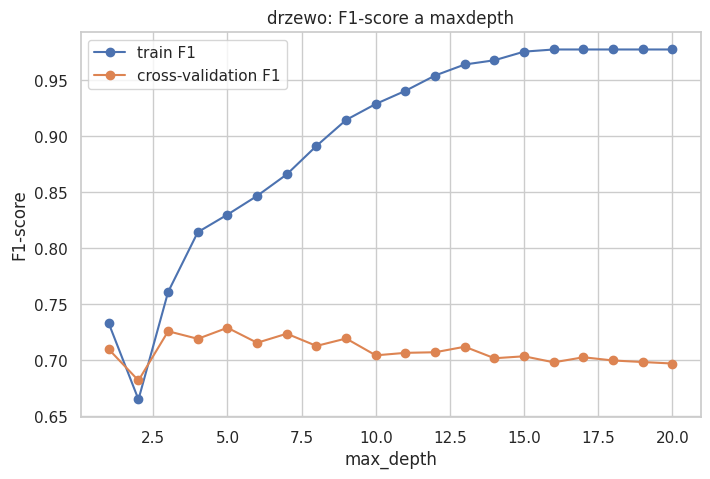

najlepsza depth : 5


In [356]:
depths=list(range(1, 21))
f1traindt=[]
f1cvdt=[]

for d in depths:
  model=DecisionTreeClassifier(max_depth=d,random_state=42)
  # wynik na calym zbiorze treningowym
  model.fit(Xtrainsc,ytrain)
  f1traindt.append(f1_score(ytrain,model.predict(Xtrainsc)))
  # walidacja krzyzowa (5 foldow treningowego)
  cvscores=cross_val_score(model,Xtrainsc,ytrain,cv=5,scoring='f1')
  f1cvdt.append(cvscores.mean())

plt.figure(figsize=(8,5))
plt.plot(depths,f1traindt,label='train F1',marker='o')
plt.plot(depths,f1cvdt,label='cross-validation F1',marker='o')
plt.title('drzewo: F1-score a maxdepth')
plt.xlabel('max_depth')
plt.ylabel('F1-score')
plt.legend()
plt.show()
# najlepsza glebokosc z np.argmax
bestdepth=depths[np.argmax(f1cvdt)]
print(f'najlepsza depth : {bestdepth}')

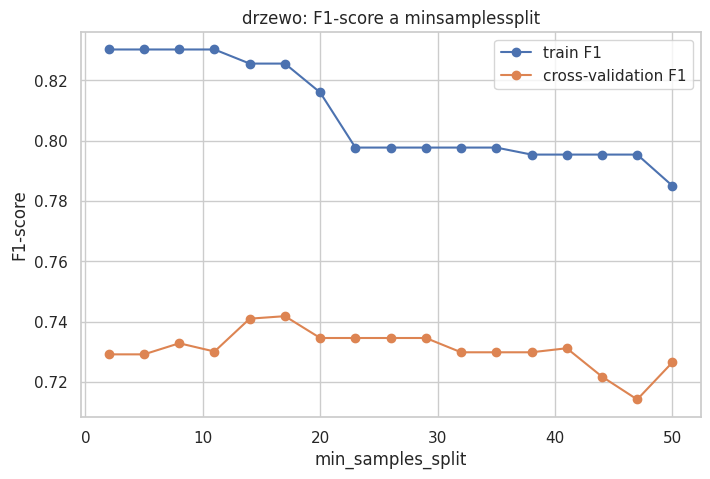

najlepszy minsamplessplit:17


In [357]:
splits=list(range(2,51,3))
f1trainsp=[]
f1cvsp=[]

for s in splits:
  model=DecisionTreeClassifier(max_depth=bestdepth,min_samples_split=s,random_state=42)
  model.fit(Xtrainsc,ytrain)
  f1trainsp.append(f1_score(ytrain,model.predict(Xtrainsc)))
  cvscores=cross_val_score(model,Xtrainsc,ytrain,cv=5,scoring='f1')
  f1cvsp.append(cvscores.mean())

plt.figure(figsize=(8,5))
plt.plot(splits,f1trainsp,label='train F1',marker='o')
plt.plot(splits,f1cvsp,label='cross-validation F1',marker='o')
plt.title('drzewo: F1-score a minsamplessplit')
plt.xlabel('min_samples_split')
plt.ylabel('F1-score')
plt.legend()
plt.show()

bestsplit=splits[np.argmax(f1cvsp)]
print(f'najlepszy minsamplessplit:{bestsplit}')

na wykresach widac kiedy nastepuje overfitting modelu

dla maxdepth bliskiego 20 drzewo ma prawie 100% na danych treningowych a na cross validation wynik spadaa bo model sie nauczyl danych na pamiec :(

dlatego sie uzywa np punktu maxdepth=5 zeby model mogl dobrze generalizowac

decision teer
wyniki treningowe:
Accuracy: 0.8694
F1-score: 0.8255

wyniki testowe:
Accuracy: 0.8101
F1-score: 0.7463


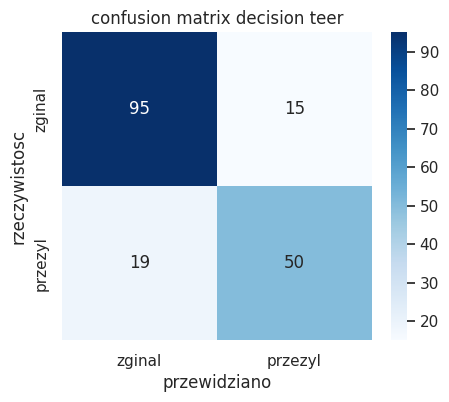

DecisionTreeClassifier(max_depth=5, min_samples_split=17, random_state=42)

In [358]:
dtfinal=DecisionTreeClassifier(max_depth=bestdepth,min_samples_split=bestsplit,random_state=42)
finalmark(dtfinal,Xtrainsc,ytrain,Xtestsc,ytest,'decision teer')


6. MODEL 2: KNN

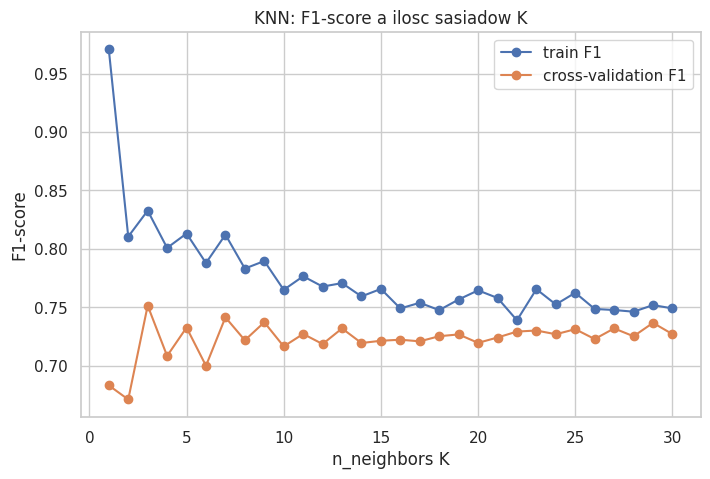

najlepsze K 3


In [359]:
kvalues=list(range(1,31))
f1trainknn=[]
f1cvknn=[]

for k in kvalues:
  model=KNeighborsClassifier(n_neighbors=k)
  model.fit(Xtrainsc,ytrain)
  f1trainknn.append(f1_score(ytrain,model.predict(Xtrainsc)))
  cvscores=cross_val_score(model,Xtrainsc,ytrain,cv=5,scoring='f1')
  f1cvknn.append(cvscores.mean())

plt.figure(figsize=(8,5))
plt.plot(kvalues,f1trainknn,label='train F1',marker='o')
plt.plot(kvalues,f1cvknn,label='cross-validation F1',marker='o')
plt.title('KNN: F1-score a ilosc sasiadow K')
plt.xlabel('n_neighbors K')
plt.ylabel('F1-score')
plt.legend()
plt.show()

bestk=kvalues[np.argmax(f1cvknn)]
print(f'najlepsze K {bestk}')

In [360]:
weightsopt=['uniform','distance']
weightsres={}

for w in weightsopt:
    model=KNeighborsClassifier(n_neighbors=bestk,weights=w)
    cvscores=cross_val_score(model,Xtrainsc,ytrain,cv=5,scoring='f1')
    weightsres[w]=cvscores.mean()

bestweight=max(weightsres,key=weightsres.get)
print(f'porownanie wag: {weightsres}')
print(f'najlepsza waga: {bestweight}')

porownanie wag: {'uniform': np.float64(0.7514208578569848), 'distance': np.float64(0.7126602330485825)}
najlepsza waga: uniform


dla K=1 KNN rowiez ma wynik rzedu 1.0 (100%) na danych treningowych (wskazuje sam na siebie)

oczywiscie zwiekszenie k zapobiega temu

KNN
wyniki treningowe:
Accuracy: 0.8764
F1-score: 0.8327

wyniki testowe:
Accuracy: 0.7765
F1-score: 0.7059


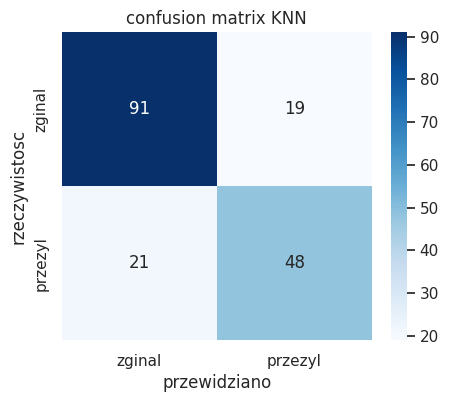

KNeighborsClassifier(n_neighbors=3)

In [361]:
knnfinal=KNeighborsClassifier(n_neighbors=bestk,weights=bestweight)
finalmark(knnfinal,Xtrainsc,ytrain,Xtestsc,ytest,'KNN')

7. PODSUMOWANIE

nie nastapil leak, a zbior testowy Xtest byl tylko do finalnego sprawdzenia; caly wybor paramow odbywal sie za pomoca walidacji na zbiorze Xtrain

dummy classifier zawsze strzelal 'zginal' osiagajac 61% Accuracy oraz F1-score 0. Ogolnie modele uzyskaly ok 80% skutecznosci

F1-score okazal sie niezbedny dla tak niezbalansowanego zbioru gdyz wskaznik Accuracy moze falszywie rosnac jesli mopdel faworyzowalby klase wiekszosciowa :(